# EDA by plots

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

import os

PATH_DATA = "transformed_data/"
PATH_PLOT = "plots/"
MONTH_ORDER = ["jan","feb","mar","apr","may","jun","jul","aug","sep","oct","nov","dec"]

os.makedirs(PATH_PLOT, exist_ok=True)

In [20]:
df = pd.read_csv(PATH_DATA + "data_grid_pv_transformed_subset.csv", index_col=0)

In [21]:
df.head()

,time,total_grid,bought_grid,excess_produced,compensated,compensation_rate,sold_grid,nighttime_bought_grid,wasted_production,temperature,...,month,year,pv_produced,pv_self_consumed,consumption,pv_self_consumption_rate,production_consumption_ratio,self_sufficiency_ratio_total,self_sufficiency_ratio_daytime,wasted_production_rate
0,2023-01-01 00:00:00+02:00,36.59,36.59,0.0,0.0,0.0,0.0,31.19,0.0,-0.60,...,jan,2023,0.0,0.0,36.59,0.0,0.0,0.0,0.0,0.0
1,2023-01-02 00:00:00+02:00,74.13,74.13,0.0,0.0,0.0,0.0,54.91,0.0,-2.22,...,jan,2023,0.0,0.0,74.13,0.0,0.0,0.0,0.0,0.0
2,2023-01-03 00:00:00+02:00,56.72,56.72,0.0,0.0,0.0,0.0,42.15,0.0,-0.28,...,jan,2023,0.0,0.0,56.72,0.0,0.0,0.0,0.0,0.0
3,2023-01-04 00:00:00+02:00,55.46,55.46,0.0,0.0,0.0,0.0,42.48,0.0,-3.97,...,jan,2023,0.0,0.0,55.46,0.0,0.0,0.0,0.0,0.0
4,2023-01-05 00:00:00+02:00,58.26,58.26,0.0,0.0,0.0,0.0,48.03,0.0,-10.01,...,jan,2023,0.0,0.0,58.26,0.0,0.0,0.0,0.0,0.0


In [22]:
df_2 = df.groupby("month")[["pv_self_consumed", "consumption"]].mean().reindex(MONTH_ORDER).reset_index()
df_3 = df.groupby("month")[["pv_self_consumed", "consumption", "nighttime_bought_grid"]].mean().reindex(MONTH_ORDER).reset_index()
df_4 = df.groupby("month")["wasted_production"].mean().reindex(MONTH_ORDER).reset_index()
df_5 = df.groupby("month")["wasted_production_rate"].mean().reindex(MONTH_ORDER).reset_index()

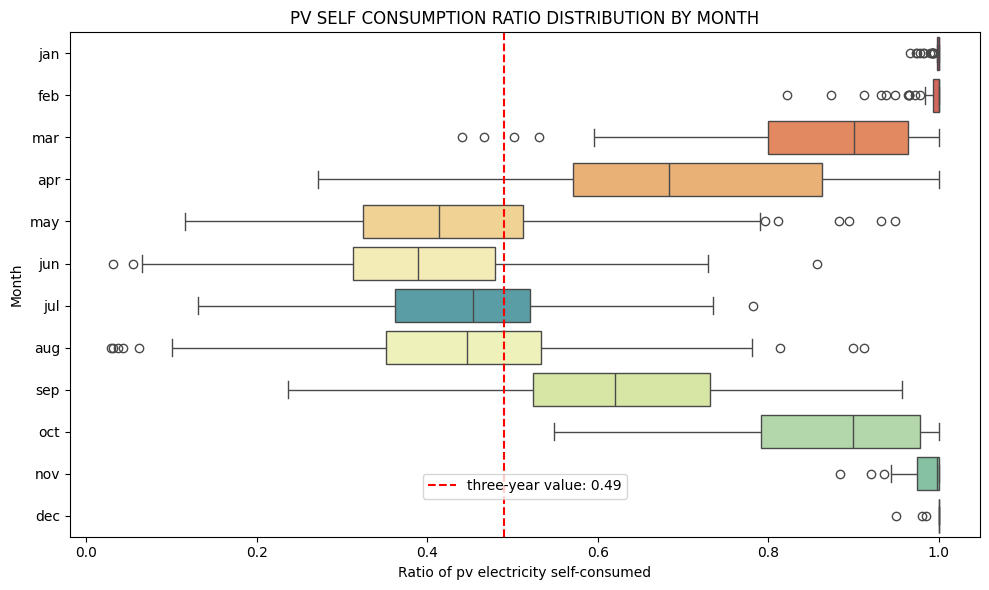

In [23]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df[df["pv_self_consumption_rate"] != 0], x="pv_self_consumption_rate", y="month", order=MONTH_ORDER, hue="month", palette="Spectral")

plt.xlabel("Ratio of pv electricity self-consumed")
plt.ylabel("Month")
plt.title("PV SELF CONSUMPTION RATIO DISTRIBUTION BY MONTH")
plt.tight_layout()

overal_ratio = (df["pv_self_consumed"].sum() /  df["pv_produced"].sum()).round(2)

plt.axvline(
    x=overal_ratio,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"three-year value: {overal_ratio}",
)

plt.legend(bbox_to_anchor=(0.5, 0.1), loc="center")
plt.savefig(PATH_PLOT + 'self_consumption_ratio_box.pdf', format='pdf', bbox_inches='tight')
plt.show()

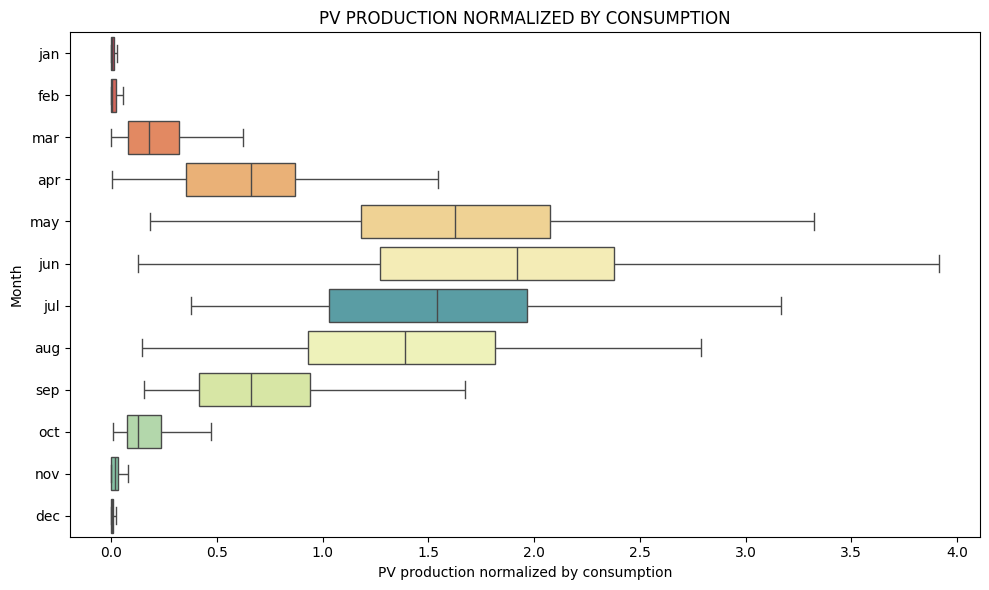

In [24]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x="production_consumption_ratio", y="month", order=MONTH_ORDER, hue="month", palette="Spectral", showfliers=False)

plt.xlabel("PV production normalized by consumption")
plt.ylabel("Month")
plt.title("PV PRODUCTION NORMALIZED BY CONSUMPTION")
plt.tight_layout()
plt.savefig(PATH_PLOT + 'normalized_production_box.pdf', format='pdf', bbox_inches='tight')
plt.show()

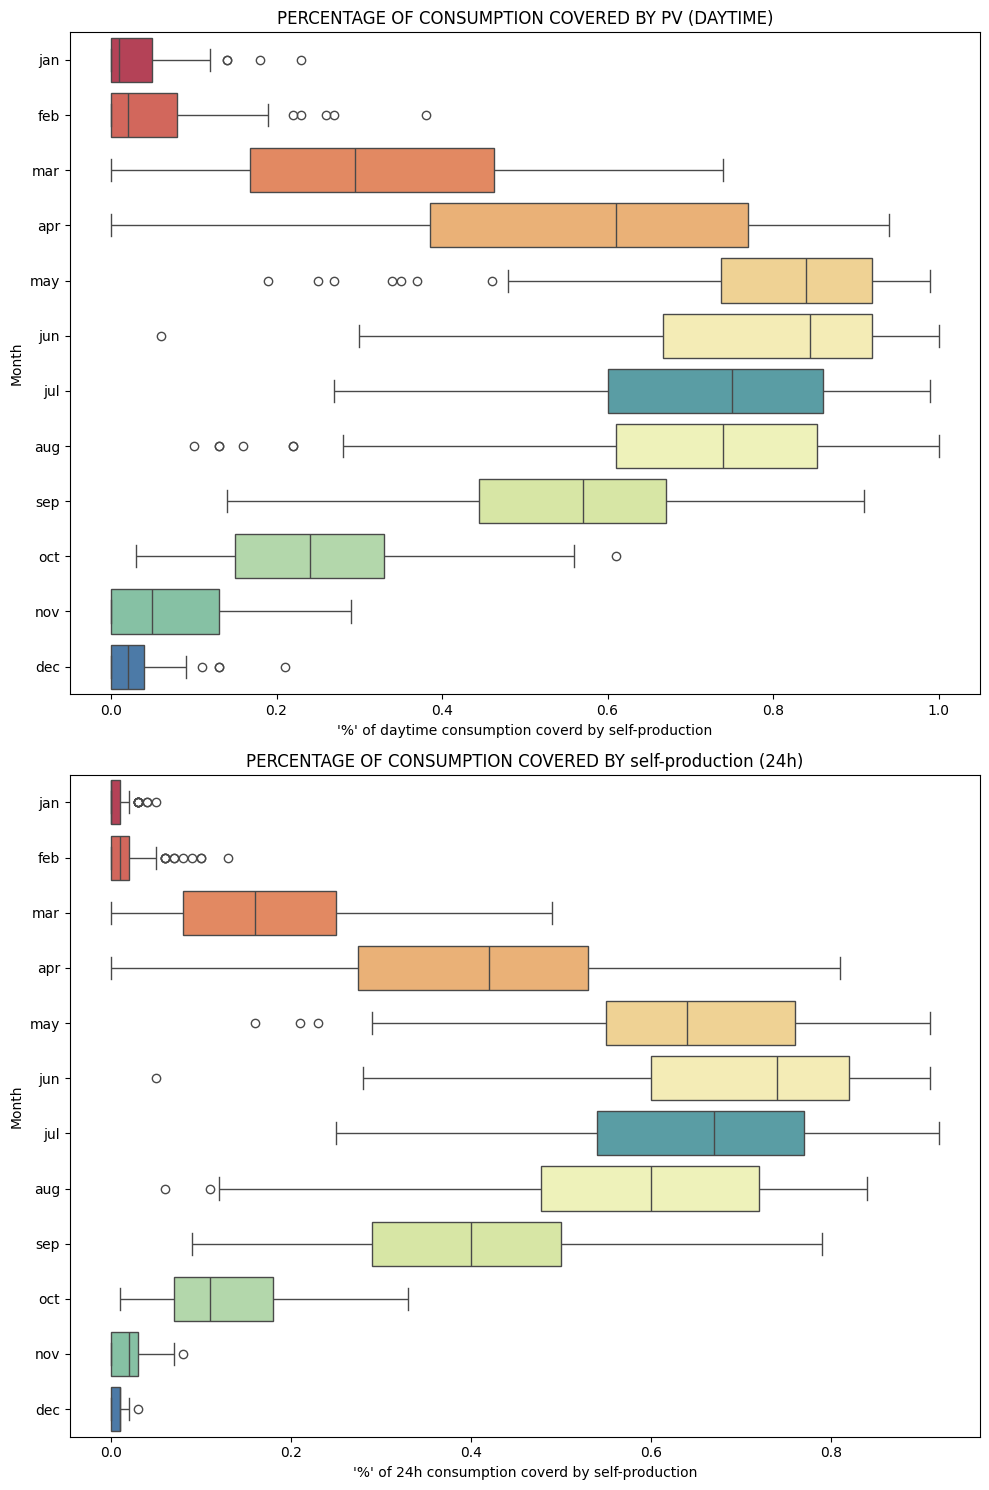

In [25]:
fig, axes = plt.subplots(2, 1, figsize=(10, 15), sharex=False)

sns.boxplot(data=df, x="self_sufficiency_ratio_daytime", y="month", order=MONTH_ORDER, hue="month", palette="Spectral", ax=axes[0])
axes[0].set_xlabel("'%' of daytime consumption coverd by self-production")
axes[0].set_ylabel("Month")
axes[0].set_title("PERCENTAGE OF CONSUMPTION COVERED BY PV (DAYTIME)")

sns.boxplot(data=df, x="self_sufficiency_ratio_total", y="month", order=MONTH_ORDER, hue="month", palette="Spectral", ax=axes[1])
axes[1].set_xlabel("'%' of 24h consumption coverd by self-production")
axes[1].set_ylabel("Month")
axes[1].set_title("PERCENTAGE OF CONSUMPTION COVERED BY self-production (24h)")
plt.tight_layout()
plt.savefig(PATH_PLOT + 'self_sufficiency_box.pdf', format='pdf', bbox_inches='tight')
plt.show()

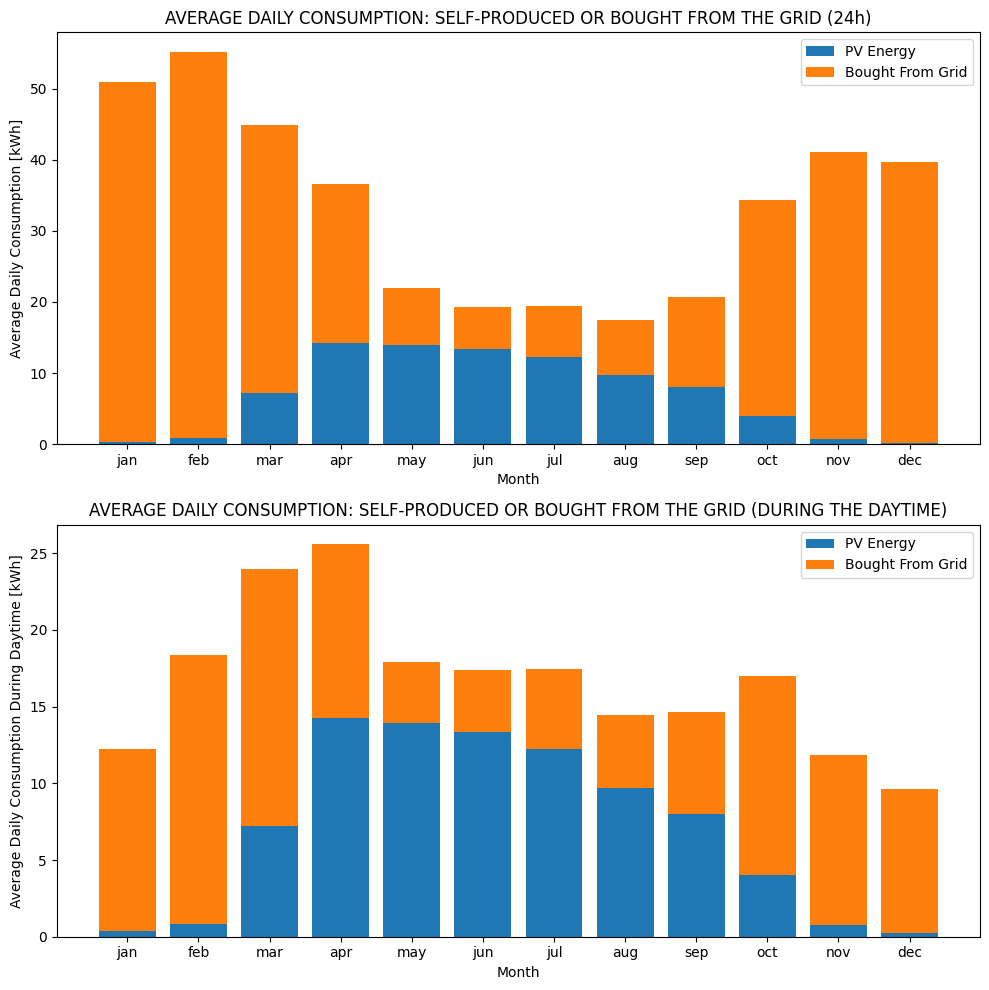

In [26]:
fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=False)

axes[0].bar(df_2["month"], df_2["pv_self_consumed"], label="PV Energy", color="#1f77b4")
axes[0].bar(df_2["month"], df_2["consumption"] - df_2["pv_self_consumed"], bottom=df_2["pv_self_consumed"], label="Bought From Grid", color="#ff7f0e")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Average Daily Consumption [kWh]")
axes[0].set_title("AVERAGE DAILY CONSUMPTION: SELF-PRODUCED OR BOUGHT FROM THE GRID (24h)")
axes[0].legend()

axes[1].bar(df_3["month"], df_3["pv_self_consumed"], label="PV Energy", color="#1f77b4")
axes[1].bar(df_3["month"], df_3["consumption"] - df_3["nighttime_bought_grid"] - df_3["pv_self_consumed"], bottom=df_2["pv_self_consumed"], label="Bought From Grid", color="#ff7f0e")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Average Daily Consumption During Daytime [kWh]")
axes[1].set_title("AVERAGE DAILY CONSUMPTION: SELF-PRODUCED OR BOUGHT FROM THE GRID (DURING THE DAYTIME)")

plt.tight_layout()
axes[1].legend()
plt.savefig(PATH_PLOT + 'daily_consumption_bar.pdf', format='pdf', bbox_inches='tight')
plt.show()

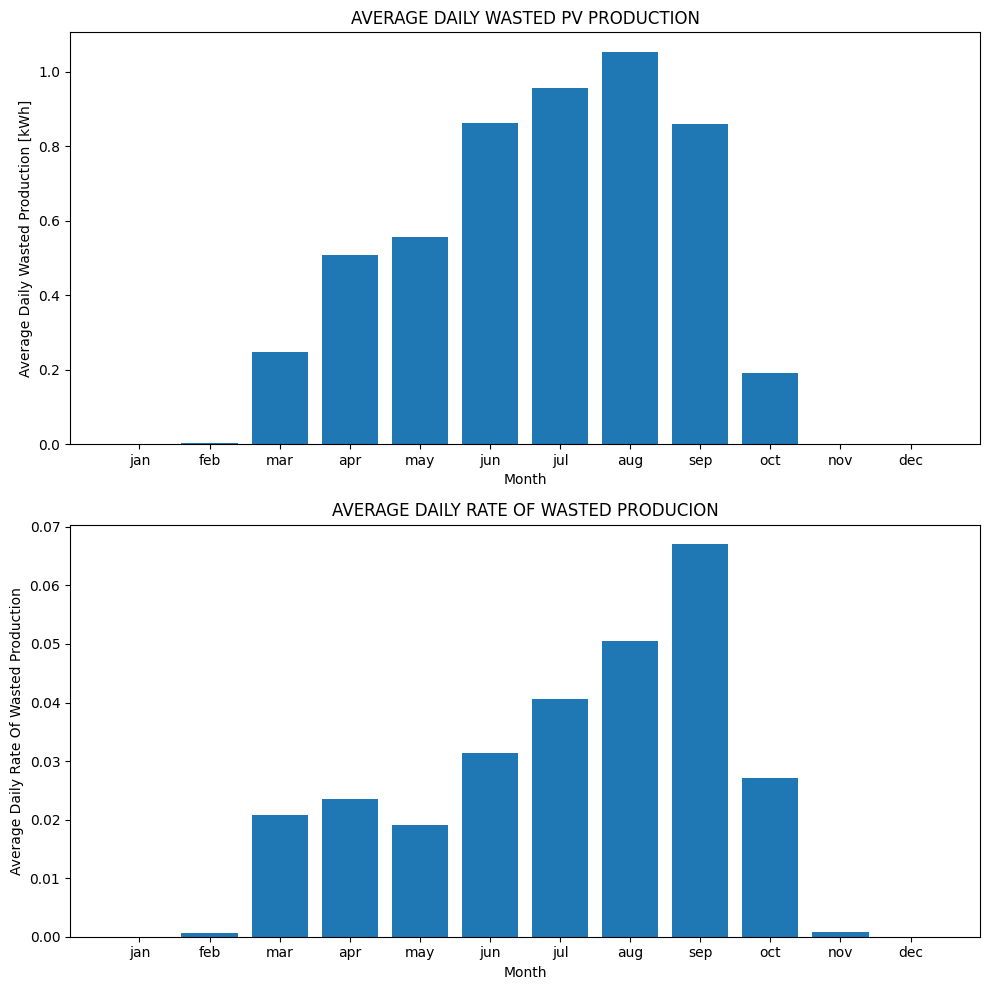

In [27]:
fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=False)

axes[0].bar(df_4["month"], df_4["wasted_production"], color="#1f77b4")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Average Daily Wasted Production [kWh]")
axes[0].set_title("AVERAGE DAILY WASTED PV PRODUCTION")

axes[1].bar(df_5["month"], df_5["wasted_production_rate"], color="#1f77b4")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Average Daily Rate Of Wasted Production")
axes[1].set_title("AVERAGE DAILY RATE OF WASTED PRODUCION")

plt.tight_layout()
plt.savefig(PATH_PLOT + 'wasted_production_bar.pdf', format='pdf', bbox_inches='tight')
plt.show()

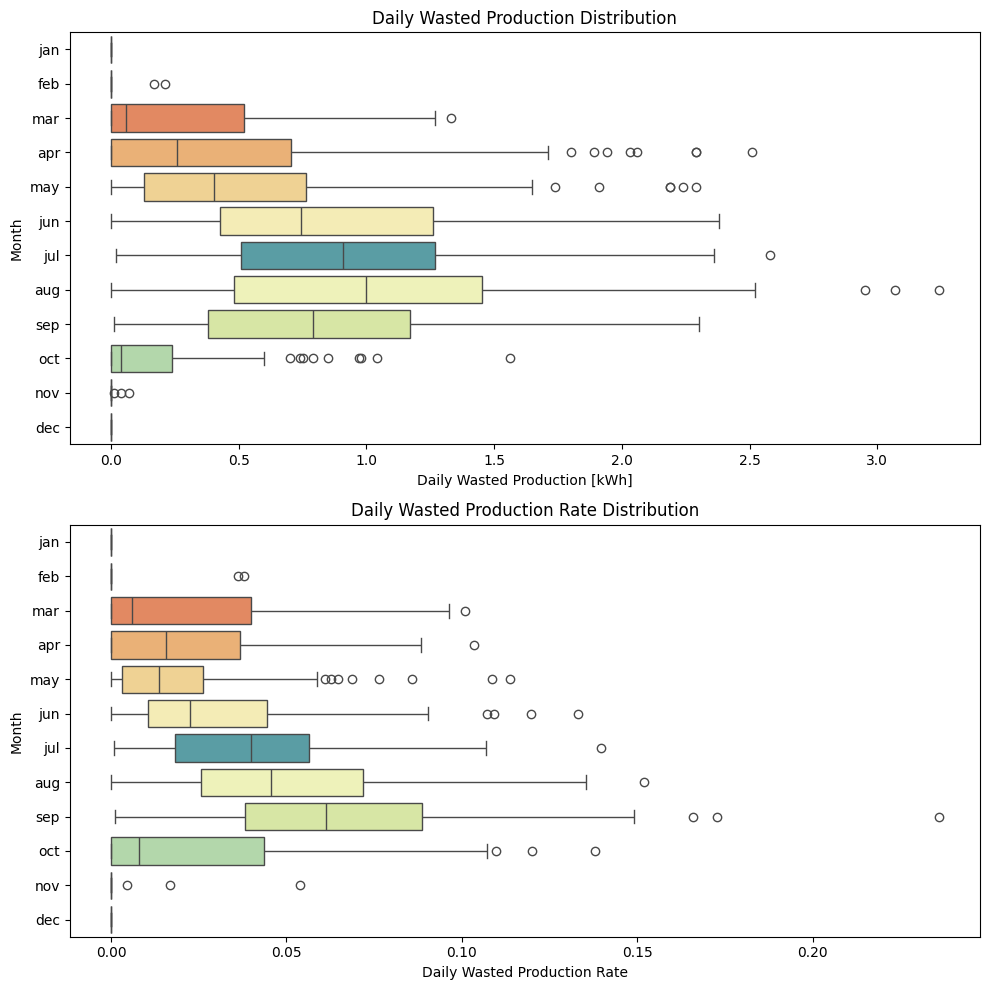

In [28]:
fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=False)


sns.boxplot(data=df, x="wasted_production", y="month", order=MONTH_ORDER, hue="month", palette="Spectral", ax=axes[0])
axes[0].set_xlabel("Daily Wasted Production [kWh]")
axes[0].set_ylabel("Month")
axes[0].set_title("Daily Wasted Production Distribution")

sns.boxplot(data=df, x="wasted_production_rate", y="month", order=MONTH_ORDER, hue="month", palette="Spectral", ax=axes[1])
axes[1].set_xlabel("Daily Wasted Production Rate")
axes[1].set_ylabel("Month")
axes[1].set_title("Daily Wasted Production Rate Distribution")

plt.tight_layout()
plt.savefig(PATH_PLOT + 'wasted_production_box.pdf', format='pdf', bbox_inches='tight')
plt.show()

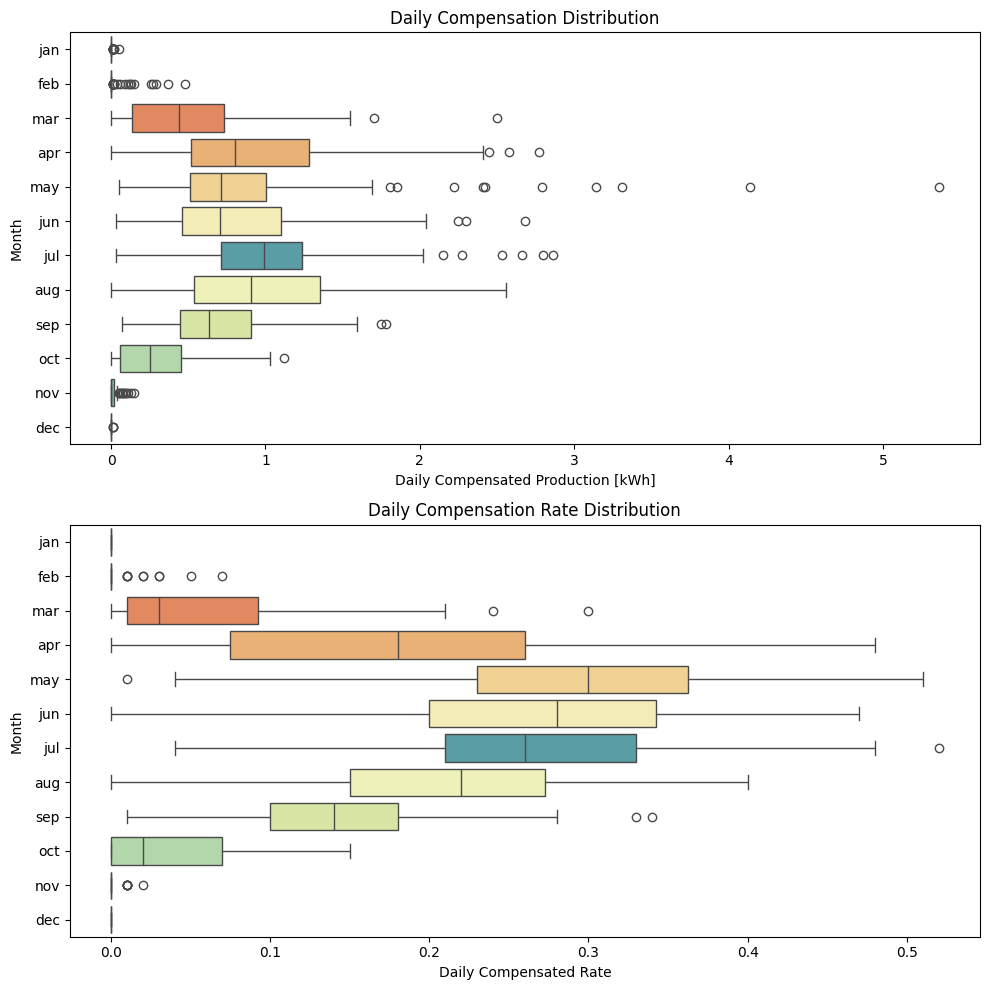

In [29]:
fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=False)


sns.boxplot(data=df, x="compensated", y="month", order=MONTH_ORDER, hue="month", palette="Spectral", ax=axes[0])
axes[0].set_xlabel("Daily Compensated Production [kWh]")
axes[0].set_ylabel("Month")
axes[0].set_title("Daily Compensation Distribution")

sns.boxplot(data=df, x="compensation_rate", y="month", order=MONTH_ORDER, hue="month", palette="Spectral", ax=axes[1])
axes[1].set_xlabel("Daily Compensated Rate")
axes[1].set_ylabel("Month")
axes[1].set_title("Daily Compensation Rate Distribution")

plt.tight_layout()
plt.savefig(PATH_PLOT + 'daily_compensation_box.pdf', format='pdf', bbox_inches='tight')
plt.show()

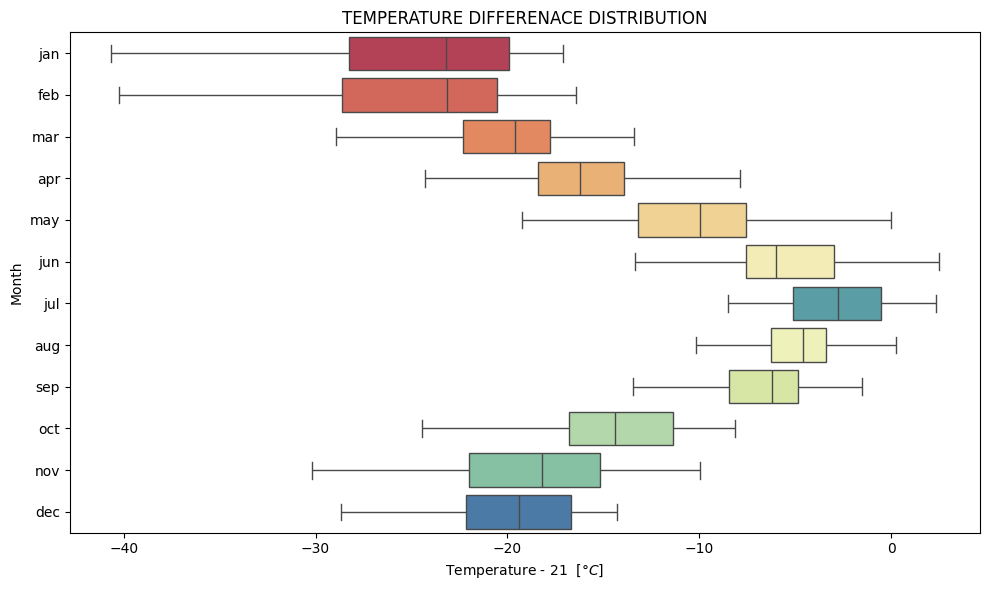

In [30]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x="temperature_diff", y="month", order=MONTH_ORDER, hue="month", palette="Spectral", showfliers=False)

plt.xlabel("Temperature - 21  [$\degree C$]")
plt.ylabel("Month")
plt.title("TEMPERATURE DIFFERENACE DISTRIBUTION")
plt.tight_layout()
plt.savefig(PATH_PLOT + 'temperature_diff_box.pdf', format='pdf', bbox_inches='tight')
plt.show()